<a href="https://colab.research.google.com/github/peachonali/Course-AI-and-Machine-Learning/blob/main/Week14_LAB10_Reinforcement%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. ให้นักศึกษาเขียนโปรแกรมภาษา Python เพื่อแก้ปัญหา Reinforcement Learning ของ Agent ที่ต้องการออกจากตึกที่มีจำนวน 5 ห้องตามตัวอย่างในชั้นเรียน (วิดีโอ YouTube) รวมถึงแสดงผลการทำงานของโปรแกรมบนหน้าจอ ดังต่อไปนี้

In [ ]:
import numpy as np

# 1. Define Reward Array (R) using np.array (instead of np.matrix for stability)
# Rows are current state, columns are Action (to Next State).
R = np.array([
    [-1, -1, -1, -1,  0, -1],
    [-1, -1, -1,  0, -1, 100],
    [-1, -1, -1,  0, -1, -1],
    [-1,  0,  0, -1,  0, -1],
    [ 0, -1, -1,  0, -1, 100],
    [-1,  0, -1, -1,  0, 100]
])

# 2. Initialize Q-Matrix to zero.
Q = np.zeros((6, 6))

# 3. Hyperparameters
gamma = 0.8
goal_state = 5

# Function to find possible Actions
def get_available_actions(state):
    current_state_row = R[state]
    # Use [0] because current_state_row is a 1D array.
    available_act = np.where(current_state_row >= 0)[0]
    return available_act

# Random Action selection function
def sample_next_action(available_actions_range):
    # Fix: Don't include 1 and don't wrap int() redundantly to avoid DeprecationWarning.
    next_action = np.random.choice(available_actions_range)
    return next_action

# 4. Update Q-Value
def update(current_state, action, gamma):
    # Find the Max Q value of the next state.
    # Fix: Changed from [1] to [0] because Q[action] is a 1D array.
    max_index = np.where(Q[action] == np.max(Q[action]))[0]
    if max_index.shape[0] > 1:
        max_index = np.random.choice(max_index)
    else:
        max_index = max_index[0]
    max_value = Q[action, max_index]

    # Bellman Equation
    Q[current_state, action] = R[current_state, action] + gamma * max_value

# 5. Training (learning)
for i in range(10000):
    current_state = np.random.randint(0, Q.shape[0])
    available_act = get_available_actions(current_state)
    action = sample_next_action(available_act)
    update(current_state, action, gamma)
print("Trained Q-Matrix (Normalized):")

if np.max(Q) > 0:
    print(np.round(Q / np.max(Q) * 100, 2))
else:
    print(Q)

# 6. Testing หลังทำ # 5. Training (learning) 10000 รอบ ก็มาทำอันนี้ต่อในการทดสอบ
def find_path(start_state):
    current_state = start_state
    steps = [current_state]

    while current_state != goal_state:
        # Select the best action from the Q-table.
        next_step_index = np.where(Q[current_state] == np.max(Q[current_state]))[0]

        if next_step_index.shape[0] > 1:
            next_step_index = np.random.choice(next_step_index)
        else:
            next_step_index = next_step_index[0]

        steps.append(int(next_step_index))
        current_state = next_step_index

    return steps

# Test
start_room = 0
path = find_path(start_room)
print(f"\nBest path from room {start_room} to outside: {path}")

Trained Q-Matrix (Normalized):
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [  0.   80.   51.2   0.   80.    0. ]
 [ 64.    0.    0.   64.    0.  100. ]
 [  0.   80.    0.    0.   80.  100. ]]

Best path from room 0 to outside: [0, 4, 5]


#2. ให้นักศึกษาปรับปรุงโปรแกรมจากข้อที่ 1 โดยให้โปรแกรมแสดงค่า Matrix Q ทุกการเรียนรู้ทุกๆ 1,000 ครั้ง และหลังจากการเรียนรู้เสร็จแล้ว ให้ผู้ใช้งานสามารถป้อนค่าเลขของห้องที่ Agent อยู่อาศัยได้

In [ ]:
import numpy as np

# 1. Define Reward Array (R) using np.array (instead of np.matrix for stability)
# Rows are current state, columns are Action (to Next State).
R = np.array([
    [-1, -1, -1, -1,  0, -1],
    [-1, -1, -1,  0, -1, 100],
    [-1, -1, -1,  0, -1, -1],
    [-1,  0,  0, -1,  0, -1],
    [ 0, -1, -1,  0, -1, 100],
    [-1,  0, -1, -1,  0, 100]
])

# 2. Initialize Q-Matrix to zero.
Q = np.zeros((6, 6))

# 3. Hyperparameters
gamma = 0.8
goal_state = 5

# Function to find possible Actions
def get_available_actions(state):
    current_state_row = R[state]
    # Use [0] because current_state_row is a 1D array.
    available_act = np.where(current_state_row >= 0)[0]
    return available_act

# Random Action selection function
def sample_next_action(available_actions_range):
    # Fix: Don't include 1 and don't wrap int() redundantly to avoid DeprecationWarning.
    next_action = np.random.choice(available_actions_range)
    return next_action

# 4. Update Q-Value
def update(current_state, action, gamma):
    # Find the Max Q value of the next state.
    # Fix: Changed from [1] to [0] because Q[action] is a 1D array.
    max_index = np.where(Q[action] == np.max(Q[action]))[0]
    if max_index.shape[0] > 1:
        max_index = np.random.choice(max_index)
    else:
        max_index = max_index[0]
    max_value = Q[action, max_index]

    # Bellman Equation
    Q[current_state, action] = R[current_state, action] + gamma * max_value

# 5. Training (learning)
for i in range(10000):
    current_state = np.random.randint(0, Q.shape[0])
    available_act = get_available_actions(current_state)
    action = sample_next_action(available_act)
    update(current_state, action, gamma)

    # ข้อ 2 ทุกๆ 1000 รอบ
    if (i + 1) % 1000 == 0:
        print("-" * 75)
        print(f"\nQ-Matrix at iteration {i+1}:")
        print("\nTrained Q-Matrix (Normalized):")
        if np.max(Q) > 0:
            print(np.round(Q / np.max(Q) * 100, 2))
        else:
            print(Q)

# 6. Testing
def find_path(start_state):
    current_state = start_state
    steps = [current_state]

    while current_state != goal_state:
        # Select the best action from the Q-table.
        next_step_index = np.where(Q[current_state] == np.max(Q[current_state]))[0]

        if next_step_index.shape[0] > 1:
            next_step_index = np.random.choice(next_step_index)
        else:
            next_step_index = next_step_index[0]

        steps.append(int(next_step_index))
        current_state = next_step_index

    return steps

# Test
start_room = int(input("\nEnter starting room (0-5): "))  # ข้อ 2
path = find_path(start_room)
print(f"\nBest path from room {start_room} to outside: {path}")

---------------------------------------------------------------------------

Q-Matrix at iteration 1000:

Trained Q-Matrix (Normalized):
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [  0.   80.   51.2   0.   80.    0. ]
 [ 64.    0.    0.   64.    0.  100. ]
 [  0.   80.    0.    0.   80.  100. ]]
---------------------------------------------------------------------------

Q-Matrix at iteration 2000:

Trained Q-Matrix (Normalized):
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [  0.   80.   51.2   0.   80.    0. ]
 [ 64.    0.    0.   64.    0.  100. ]
 [  0.   80.    0.    0.   80.  100. ]]
---------------------------------------------------------------------------

Q-Matrix at iteration 3000:

Trained Q-Matrix (Normalized):
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [

#3. ให้นักศึกษาปรับปรุงโปรแกรมจากข้อที่ 1 โดยเปลี่ยน Layout ของห้องและตึกเป็นตามรูปด้านล่างนี้กำหนดให้ Agent เริ่มต้นอยู่ที่ห้องหมายเลข 0 และเดินทางออกไปนอกตึก (ห้องหมายเลข 5) ให้แสดง ผลลัพธ์ว่า Agent ต้องเดินผ่านห้องใดบ้าง

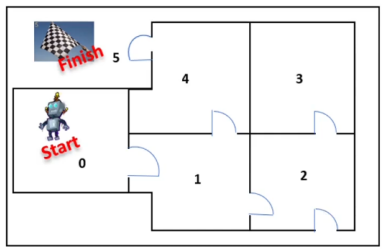

In [ ]:
import numpy as np

# 1. Define Reward Array (R) using np.array (instead of np.matrix for stability)
# Rows are current state, columns are Action (to Next State).
# ข้อ 3 R
R = np.array([
    [-1,  0, -1, -1, -1, -1],   # 0 → 1
    [ 0, -1,  0, -1,  0, -1],   # 1 → 0,2,4
    [-1,  0, -1,  0, -1, -1],   # 2 → 1,3
    [-1, -1,  0, -1, -4, -1],   # 3 → 2
    [-1,  0, -1, -1, -1, 500],  # 4 → 1,5
    [-1, -1, -1, -1,  0, 500]   # 5 → 4,5(exit)
])

# 2. Initialize Q-Matrix to zero.
Q = np.zeros((6, 6))

# 3. Hyperparameters
gamma = 0.8
goal_state = 5  # ข้อ 3

# Function to find possible Actions
def get_available_actions(state):
    current_state_row = R[state]
    # Use [0] because current_state_row is a 1D array.
    available_act = np.where(current_state_row >= 0)[0]
    return available_act

# Random Action selection function
def sample_next_action(available_actions_range):
    # Fix: Don't include 1 and don't wrap int() redundantly to avoid DeprecationWarning.
    next_action = np.random.choice(available_actions_range)
    return next_action

# 4. Update Q-Value
def update(current_state, action, gamma):
    # Find the Max Q value of the next state.
    # Fix: Changed from [1] to [0] because Q[action] is a 1D array.
    max_index = np.where(Q[action] == np.max(Q[action]))[0]
    if max_index.shape[0] > 1:
        max_index = np.random.choice(max_index)
    else:
        max_index = max_index[0]
    max_value = Q[action, max_index]

    # Bellman Equation
    Q[current_state, action] = R[current_state, action] + gamma * max_value

# 5. Training (learning)
for i in range(10000):
    current_state = np.random.randint(0, Q.shape[0])
    available_act = get_available_actions(current_state)
    action = sample_next_action(available_act)
    update(current_state, action, gamma)
print("Trained Q-Matrix (Normalized):")

if np.max(Q) > 0:
    print(np.round(Q / np.max(Q) * 100, 2))
else:
    print(Q)

# 6. Testing
def find_path(start_state):
    current_state = start_state
    steps = [current_state]

    while current_state != goal_state:
        # Select the best action from the Q-table.
        next_step_index = np.where(Q[current_state] == np.max(Q[current_state]))[0]

        if next_step_index.shape[0] > 1:
            next_step_index = np.random.choice(next_step_index)
        else:
            next_step_index = next_step_index[0]

        steps.append(int(next_step_index))
        current_state = next_step_index

    return steps

# Test
start_room = 0  # ข้อ 3
path = find_path(start_room)
print(f"\nBest path from room {start_room} to outside: {path}")

Trained Q-Matrix (Normalized):
[[  0.    64.     0.     0.     0.     0.  ]
 [ 51.2    0.    51.2    0.    80.     0.  ]
 [  0.    64.     0.    40.96   0.     0.  ]
 [  0.     0.    51.2    0.     0.     0.  ]
 [  0.    64.     0.     0.     0.   100.  ]
 [  0.     0.     0.     0.    80.   100.  ]]

Best path from room 0 to outside: [0, 1, 4, 5]


#สรุปผลการทดลอง

**การทดลองนี้เป็นการใช้ Q-Learning** เพื่อให้เอเจนต์เรียนรู้เส้นทางที่ดีที่สุดจากการลองเดินในสภาพแวดล้อม (Reward Matrix) จำนวน 10,000 รอบ โดยในช่วงการฝึก เอเจนต์จะสุ่มเลือก state และ action จากนั้นอัปเดตค่า Q-table ด้วยสมการ Bellman เพื่อสะสมประสบการณ์เกี่ยวกับผลตอบแทนของแต่ละการกระทำ เมื่อฝึกเสร็จแล้ว Q-table จะเก็บค่าความเหมาะสมของแต่ละเส้นทางไว้ และในขั้นตอนการทดสอบ เอเจนต์จะใช้ Q-table ที่เรียนรู้มาแล้วในการเลือก action ที่มีค่า Q สูงสุดในแต่ละ state เพื่อเดินทางจากจุดเริ่มต้นไปยัง state เป้าหมายได้อย่างมีประสิทธิภาพโดยไม่ต้องเรียนรู้ใหม่อีกครั้ง ผลการทดลองแสดงให้เห็นว่าเอเจนต์สามารถค้นหาเส้นทางที่ดีที่สุดได้หลังจากการฝึก และสามารถนำความรู้ที่ได้ไปใช้งานจริงในการนำทางได้อย่างถูกต้อง
